In [1]:
import pandas as pd
import os
import numpy as np
import nltk
import zipfile
import os
from bs4 import BeautifulSoup
import re
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
from nltk.tokenize import word_tokenize


In [2]:
from google.colab import files
uploaded = files.upload()

Saving Administration, economics and law.csv to Administration, economics and law.csv
Saving Body and beauty care.csv to Body and beauty care.csv
Saving Building and construction.csv to Building and construction.csv
Saving Crafts.csv to Crafts.csv
Saving Culture, media, design.csv to Culture, media, design.csv
Saving Data & IT.csv to Data & IT.csv
Saving Decontamination and sanitation.csv to Decontamination and sanitation.csv
Saving Health care.csv to Health care.csv
Saving Hotel, restaurant, catering.csv to Hotel, restaurant, catering.csv
Saving Industrial manufacturing.csv to Industrial manufacturing.csv
Saving Installation, operation and maintenance.csv to Installation, operation and maintenance.csv
Saving Managers and supervisors.csv to Managers and supervisors.csv
Saving Military occupations.csv to Military occupations.csv
Saving Natural agriculture.csv to Natural agriculture.csv
Saving Pedagogical occupations.csv to Pedagogical occupations.csv
Saving Sales, purchasing and marketi

In [3]:
# Load jobs CSV files by name, keeping only title_en column
jobs_files = [
    'Administration, economics and law.csv', 'Body and beauty care.csv',
    'Building and construction.csv', 'Crafts.csv', 'Culture, media, design.csv',
    'Data & IT.csv', 'Decontamination and sanitation.csv', 'Health care.csv',
    'Hotel, restaurant, catering.csv', 'Industrial manufacturing.csv',
    'Installation, operation and maintenance.csv', 'Managers and supervisors.csv',
    'Military occupations.csv', 'Natural agriculture.csv', 'Pedagogical occupations.csv',
    'Sales, purchasing and marketing.csv', 'Security and surveillance.csv',
    'Social occupations.csv', 'Technical occupations.csv',
    'Transport, distribution, storage.csv'
]

loaded_dfs = []
successfully_loaded = []
failed_to_load = []

for filename in jobs_files:
    if filename in uploaded:  # file was uploaded
        try:
            df = pd.read_csv(filename, usecols=["title_en"])  # <-- only load title_en
            loaded_dfs.append(df)
            successfully_loaded.append(filename)
        except Exception as e:
            print(f"Error loading {filename}: {e}")
            failed_to_load.append(filename)
    else:
        failed_to_load.append(filename)

# Concatenate all loaded dataframes
if loaded_dfs:
    jobs_df_final = pd.concat(loaded_dfs, ignore_index=True)
else:
    jobs_df_final = pd.DataFrame(columns=["title_en"])  # empty fallback

# Summary
print(f"Files uploaded this session: {list(uploaded.keys())}")
print(f"Files successfully loaded: {successfully_loaded}")
print(f"Files not uploaded or failed to load: {failed_to_load}")

print(f"\nTotal rows in combined jobs_df_final: {len(jobs_df_final)}")
print(jobs_df_final.head())

Files uploaded this session: ['Administration, economics and law.csv', 'Body and beauty care.csv', 'Building and construction.csv', 'Crafts.csv', 'Culture, media, design.csv', 'Data & IT.csv', 'Decontamination and sanitation.csv', 'Health care.csv', 'Hotel, restaurant, catering.csv', 'Industrial manufacturing.csv', 'Installation, operation and maintenance.csv', 'Managers and supervisors.csv', 'Military occupations.csv', 'Natural agriculture.csv', 'Pedagogical occupations.csv', 'Sales, purchasing and marketing.csv', 'Security and surveillance.csv', 'Social occupations.csv', 'Technical occupations.csv', 'Transport, distribution, storage.csv']
Files successfully loaded: ['Administration, economics and law.csv', 'Body and beauty care.csv', 'Building and construction.csv', 'Crafts.csv', 'Culture, media, design.csv', 'Data & IT.csv', 'Decontamination and sanitation.csv', 'Health care.csv', 'Hotel, restaurant, catering.csv', 'Industrial manufacturing.csv', 'Installation, operation and mainten

In [4]:
jobs_df_final

,title_en
0,Temporary HR Specialist - Employer Branding
1,Temporary HR Specialist- Employer Branding
2,Quality developer
3,PhD Research Fellowship in Social Work
4,Traffic Officer
...,...
1651,Warehouse worker for the Aids business in Kalix
1652,Temporary truck driver
1653,LTH is looking for summer staff - machine driv...
1654,LTH is looking for summer staff - drivers for ...


In [5]:
jobs_df_final = jobs_df_final.rename(columns={'title_en': 'job_summary'})

In [6]:
jobs_df_final

,job_summary
0,Temporary HR Specialist - Employer Branding
1,Temporary HR Specialist- Employer Branding
2,Quality developer
3,PhD Research Fellowship in Social Work
4,Traffic Officer
...,...
1651,Warehouse worker for the Aids business in Kalix
1652,Temporary truck driver
1653,LTH is looking for summer staff - machine driv...
1654,LTH is looking for summer staff - drivers for ...


In [7]:
from google.colab import files
uploaded = files.upload()

Saving 1_talents_1-500.csv to 1_talents_1-500.csv
Saving 2_talents_501-1000.csv to 2_talents_501-1000.csv
Saving 3_talents_1001-1500.csv to 3_talents_1001-1500.csv
Saving 4_talents_1501-2000.csv to 4_talents_1501-2000.csv
Saving 5_talents_2001-2500.csv to 5_talents_2001-2500.csv
Saving 6_talents_2501-3000.csv to 6_talents_2501-3000.csv
Saving 7_talents_3001-3500.csv to 7_talents_3001-3500.csv
Saving 8_talents_3501-4000.csv to 8_talents_3501-4000.csv
Saving 9_talents_4001-4500.csv to 9_talents_4001-4500.csv
Saving 10_talents_4501-5000.csv to 10_talents_4501-5000.csv
Saving 11_talents_5001-5500.csv to 11_talents_5001-5500.csv
Saving 12_talents_5501-6000.csv to 12_talents_5501-6000.csv
Saving 13_talents_6001-6500.csv to 13_talents_6001-6500.csv
Saving 14_talents_6501-7000.csv to 14_talents_6501-7000.csv


In [8]:
# List of resume files
resume_files = [
    '1_talents_1-500.csv', '2_talents_501-1000.csv', '3_talents_1001-1500.csv',
    '4_talents_1501-2000.csv', '5_talents_2001-2500.csv', '6_talents_2501-3000.csv',
    '7_talents_3001-3500.csv', '8_talents_3501-4000.csv', '9_talents_4001-4500.csv',
    '10_talents_4501-5000.csv', '11_talents_5001-5500.csv', '12_talents_5501-6000.csv',
    '13_talents_6001-6500.csv', '14_talents_6501-7000.csv'
]

# Columns we want to load
resume_columns = ["about", "tools", "skills", "educations", "experiences", "certifications"]

# Initialize lists
loaded_dfs = []
successfully_loaded = []
failed_to_load = []

# Load only selected columns
for filename in resume_files:
    if filename in uploaded:
        try:
            df = pd.read_csv(filename, usecols=resume_columns)
            loaded_dfs.append(df)
            successfully_loaded.append(filename)
        except Exception as e:
            print(f"Error loading {filename}: {e}")
            failed_to_load.append(filename)
    else:
        failed_to_load.append(filename)

# Concatenate loaded DataFrames if any
if loaded_dfs:
    resume_df_final = pd.concat(loaded_dfs, ignore_index=True)
else:
    resume_df_final = pd.DataFrame(columns=resume_columns)  # Empty fallback

# Print summary
print(f"Files uploaded this session: {list(uploaded.keys())}")
print(f"Files successfully loaded: {successfully_loaded}")
print(f"Files not uploaded or failed to load: {failed_to_load}")
print(f"\nTotal rows in combined resume_df: {len(resume_df_final)}")
print(resume_df_final.head())

Files uploaded this session: ['1_talents_1-500.csv', '2_talents_501-1000.csv', '3_talents_1001-1500.csv', '4_talents_1501-2000.csv', '5_talents_2001-2500.csv', '6_talents_2501-3000.csv', '7_talents_3001-3500.csv', '8_talents_3501-4000.csv', '9_talents_4001-4500.csv', '10_talents_4501-5000.csv', '11_talents_5001-5500.csv', '12_talents_5501-6000.csv', '13_talents_6001-6500.csv', '14_talents_6501-7000.csv']
Files successfully loaded: ['1_talents_1-500.csv', '2_talents_501-1000.csv', '3_talents_1001-1500.csv', '4_talents_1501-2000.csv', '5_talents_2001-2500.csv', '6_talents_2501-3000.csv', '7_talents_3001-3500.csv', '8_talents_3501-4000.csv', '9_talents_4001-4500.csv', '10_talents_4501-5000.csv', '11_talents_5001-5500.csv', '12_talents_5501-6000.csv', '13_talents_6001-6500.csv', '14_talents_6501-7000.csv']
Files not uploaded or failed to load: []

Total rows in combined resume_df: 6824
                                               about  \
0  I am a goal-oriented university engineer in el

In [9]:
resume_df_final

,about,tools,skills,educations,experiences,certifications
0,I am a goal-oriented university engineer in el...,"['LabVIEW', 'Python', 'Matlab', 'LTSpice', 'So...","['Electrical engineering', 'Teamwork', 'Adapta...",[{'course': 'Högskoleingenjör i elektroteknik'...,"[{'company': 'WSP', 'end_date': '2023-10-01', ...",[]
1,Master's degree in Tribology (TRIBOS+ Joint De...,[],"['MATLAB & Simulink', 'Solidworks Ansys (Mater...","[{'course': 'Tribology (TRIBOS+ Joint Degree, ...","[{'company': 'LTU Business', 'end_date': '2024...",[]
2,Currently studying at Universidad Francisco de...,"['Office Suite (Excel, Word, PowerPoint)', 'Ad...","['Pre-production departments', 'Production and...",[{'course': 'Audiovisual Communication and Adv...,"[{'company': 'Telecinco - Production', 'end_da...",NaN
3,Motivated and ambitious mechanical engineer wi...,"['Microsoft Office', 'SolidWorks', 'Gambit', '...","['Telecommunications', 'Project Management', '...","[{'course': 'Energy Conversion', 'degree': 'Ma...","[{'company': 'HIWEB holding', 'end_date': None...",NaN
4,"I am an enthusiastic kind of person, exception...",NaN,"['Working on Excel/MS Office', 'Comfortable at...",[{'course': 'MBA - INTERNATIONAL BUSINESS ADMI...,"[{'company': 'Jensens Bofhus', 'end_date': Non...",NaN
...,...,...,...,...,...,...
6819,Senior Engineering Management Professional wit...,"['PLSCADD', 'PLSPOLE', 'PLSTOWER', 'STAAD Pro']","['Project Management', 'Electrical Engineering...","[{'course': 'Strategic Leadership', 'degree': ...","[{'company': 'Sterlite Power, Gurugram', 'end_...",NaN
6820,"Excellence through hard working, loyalty, sens...",[],[],[{'course': 'Junior High School Certificate B....,"[{'company': 'SEAWORKS COMPANY (QATAR)', 'end_...",[]
6821,"Event Coordinator, experienced in Tourism. Com...",NaN,"['Teamwork', 'Problem-solving', 'Customer serv...","[{'course': 'Public Accountant', 'degree': 'nu...",[{'company': 'United Nations International Eme...,NaN
6822,Project Engineer with experience in mechanical...,"['ANSYS', 'Python', 'SQL', 'Arduino', 'LaTeX']","['Mechanical Engineering', 'Manufacturing Proc...",[{'course': 'MSc in Space Science and Technolo...,"[{'company': 'ACTAS Space', 'end_date': '2023-...",[]


In [10]:
# create the summary (your code)
resume_df_final['resume_summary'] = (
    resume_df_final[resume_columns]
    .fillna('')
    .agg(lambda x: ' '.join(x).strip(), axis=1)
)

# drop the original columns
resume_df_final.drop(columns=resume_columns, inplace=True)

In [11]:
resume_df_final

,resume_summary
0,I am a goal-oriented university engineer in el...
1,Master's degree in Tribology (TRIBOS+ Joint De...
2,Currently studying at Universidad Francisco de...
3,Motivated and ambitious mechanical engineer wi...
4,"I am an enthusiastic kind of person, exception..."
...,...
6819,Senior Engineering Management Professional wit...
6820,"Excellence through hard working, loyalty, sens..."
6821,"Event Coordinator, experienced in Tourism. Com..."
6822,Project Engineer with experience in mechanical...


In [12]:
!pip install --upgrade scipy

In [13]:
# Download necessary NLTK resources (only need to run once)
nltk.download('punkt_tab')
nltk.download('punkt')
nltk.download('stopwords')
nltk.download('wordnet')

[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.
[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.
[nltk_data] Downloading package wordnet to /root/nltk_data...


True

In [14]:
def preprocess_text(text):
    """
    Preprocesses a given text string for NLP tasks. This includes cleaning the text,
    tokenizing, removing stopwords, and lemmatizing the words.

    Args:
    text (str): The text string to preprocess.

    Returns:
    str: The preprocessed text.
    """
    if not isinstance(text, str):  # Safeguard against non-string input like NaN
        return ""

     # 1. Add spaces around tags, then remove them
    text = re.sub(r'<[^>]+>', ' ', text)

    # 2. Remove URLs
    text = re.sub(r'https?://\S+|www\.\S+', '', text)

    # 3. Remove emails
    text = re.sub(r'\b[A-Za-z0-9._%+-]+@[A-Za-z0-9.-]+\.[A-Z|a-z]{2,}\b', '', text)

    # 4. Remove special characters (keep only words and whitespace)
    text = re.sub(r'[^\w\s]', '', text)

    #5 Trip out all non-ASCII characters like â, €, ™, etc., that appear due to encoding mismatches
    text = text.encode('ascii', 'ignore').decode()

    text = text.lower()

    tokens = word_tokenize(text)
    stop_words = set(stopwords.words('english'))
    filtered_tokens = [word for word in tokens if word not in stop_words]

    lemmatizer = WordNetLemmatizer()
    lemmatized_text = [lemmatizer.lemmatize(word) for word in filtered_tokens]

    return ' '.join(lemmatized_text)

In [15]:
# Apply preprocessing
# Keep original resume text in a new column
resume_df_final['Resume_original'] = resume_df_final['resume_summary']

# Apply preprocessing only on 'Resume'
resume_df_final['resume_summary'] = resume_df_final['resume_summary'].apply(preprocess_text)


In [16]:
resume_df_final

,resume_summary,Resume_original
0,goaloriented university engineer electrical en...,I am a goal-oriented university engineer in el...
1,master degree tribology tribos joint degree er...,Master's degree in Tribology (TRIBOS+ Joint De...
2,currently studying universidad francisco de vi...,Currently studying at Universidad Francisco de...
3,motivated ambitious mechanical engineer 7 year...,Motivated and ambitious mechanical engineer wi...
4,enthusiastic kind person exceptional communica...,"I am an enthusiastic kind of person, exception..."
...,...,...
6819,senior engineering management professional 21 ...,Senior Engineering Management Professional wit...
6820,excellence hard working loyalty sense integrit...,"Excellence through hard working, loyalty, sens..."
6821,event coordinator experienced tourism committe...,"Event Coordinator, experienced in Tourism. Com..."
6822,project engineer experience mechanical calcula...,Project Engineer with experience in mechanical...


In [17]:
def drop_duplicates(df, column_name):
    """
    Drops duplicates based on a specified column from the DataFrame.

    Args:
    df (pd.DataFrame): The DataFrame from which to remove duplicates.
    column_name (str): The name of the column based on which duplicates will be identified.

    Returns:
    pd.DataFrame: DataFrame with duplicates removed based on the specified column.
    """
    if column_name not in df.columns:
        raise ValueError(f"Column '{column_name}' not found in DataFrame")

    original_size = df.shape[0]
    df_cleaned = df.drop_duplicates(subset=[column_name])
    new_size = df_cleaned.shape[0]

    print(f"Dropped {original_size - new_size} duplicates from '{column_name}'. New dataset size: {new_size}")

    return df_cleaned

In [18]:
jobs_df_final = drop_duplicates(jobs_df_final, column_name='job_summary')

Dropped 316 duplicates from 'job_summary'. New dataset size: 1340


In [19]:
#resume_df_final = df[['Resume']].rename(columns={'Resume': 'resume_summary'})
resume_df_final = drop_duplicates(resume_df_final, column_name='Resume_original')

Dropped 19 duplicates from 'Resume_original'. New dataset size: 6805


In [20]:
jobs_df_final

,job_summary
0,Temporary HR Specialist - Employer Branding
1,Temporary HR Specialist- Employer Branding
2,Quality developer
3,PhD Research Fellowship in Social Work
4,Traffic Officer
...,...
1650,Warehouse worker for the Aids business in Kalix
1652,Temporary truck driver
1653,LTH is looking for summer staff - machine driv...
1654,LTH is looking for summer staff - drivers for ...


In [21]:
resume_df_final

,resume_summary,Resume_original
0,goaloriented university engineer electrical en...,I am a goal-oriented university engineer in el...
1,master degree tribology tribos joint degree er...,Master's degree in Tribology (TRIBOS+ Joint De...
2,currently studying universidad francisco de vi...,Currently studying at Universidad Francisco de...
3,motivated ambitious mechanical engineer 7 year...,Motivated and ambitious mechanical engineer wi...
4,enthusiastic kind person exceptional communica...,"I am an enthusiastic kind of person, exception..."
...,...,...
6819,senior engineering management professional 21 ...,Senior Engineering Management Professional wit...
6820,excellence hard working loyalty sense integrit...,"Excellence through hard working, loyalty, sens..."
6821,event coordinator experienced tourism committe...,"Event Coordinator, experienced in Tourism. Com..."
6822,project engineer experience mechanical calcula...,Project Engineer with experience in mechanical...


In [22]:
!pip install -U sentence-transformers

In [23]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm.notebook import tqdm
from sentence_transformers import SentenceTransformer
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.metrics import confusion_matrix

class SentenceTransformerEncoder:
    def __init__(self, model_name='all-MiniLM-L6-v2'):
        self.model = SentenceTransformer(model_name)

    def encode_column(self, df, column, batch_size=32, encoded_column_suffix='_encoded'):
        if column not in df.columns:
            raise ValueError(f"Column '{column}' not found in DataFrame")

        encoded_vectors = []
        for start_idx in range(0, len(df), batch_size):
            end_idx = min(start_idx + batch_size, len(df))
            batch_texts = df[column][start_idx:end_idx].tolist()
            batch_encoded = self.model.encode(batch_texts, show_progress_bar=True)
            encoded_vectors.extend(batch_encoded)

        df[column + encoded_column_suffix] = encoded_vectors
        return df


In [24]:
def split_df(df, train_frac=0.8, val_frac=0.1, random_state=42):
    df_shuffled = df.sample(frac=1, random_state=random_state).reset_index(drop=True)
    n = len(df_shuffled)
    train_end = int(n * train_frac)
    val_end = int(n * (train_frac + val_frac))

    train_df = df_shuffled.iloc[:train_end].reset_index(drop=True)
    val_df = df_shuffled.iloc[train_end:val_end].reset_index(drop=True)
    test_df = df_shuffled.iloc[val_end:].reset_index(drop=True)

    return train_df, val_df, test_df

In [25]:
def perform_evaluation_run(resume_df, jobs_df, model_name='sentence-t5-base', random_seed=42, similarity_threshold=0.7):
    # Split data with the specific seed
    resume_train, resume_val, resume_test = split_df(resume_df, random_state=random_seed)
    jobs_train, jobs_val, jobs_test = split_df(jobs_df, random_state=random_seed)

    # Create encoder with the specified model
    encoder = SentenceTransformerEncoder(model_name=model_name)

    # Encode all datasets
    resume_train = encoder.encode_column(resume_train, 'resume_summary')
    resume_val = encoder.encode_column(resume_val, 'resume_summary')
    resume_test = encoder.encode_column(resume_test, 'resume_summary')

    jobs_train = encoder.encode_column(jobs_train, 'job_summary')
    jobs_val = encoder.encode_column(jobs_val, 'job_summary')
    jobs_test = encoder.encode_column(jobs_test, 'job_summary')

    # Extract embeddings as numpy arrays
    resume_test_embeds = np.vstack(resume_test['resume_summary_encoded'].values)
    jobs_test_embeds = np.vstack(jobs_test['job_summary_encoded'].values)

    # Compute similarity matrix
    similarity_matrix = cosine_similarity(resume_test_embeds, jobs_test_embeds)

    # Collect ALL matches, not just top-N
    results = []
    for resume_idx in range(similarity_matrix.shape[0]):
        for job_idx in range(similarity_matrix.shape[1]):
            score = similarity_matrix[resume_idx, job_idx]
            results.append({
                'resume_index': resume_idx,
                'job_index': job_idx,
                'similarity_score': score,
                'resume_summary': resume_test.iloc[resume_idx]['resume_summary'],
                'resume_original': resume_test.iloc[resume_idx]['Resume_original'],
                'job_summary': jobs_test.iloc[job_idx]['job_summary'],
                'is_correct': score >= similarity_threshold
            })

    matches_df = pd.DataFrame(results)

    # Calculate metrics
    metrics = {
        'avg_similarity': matches_df['similarity_score'].mean(),
        'median_similarity': matches_df['similarity_score'].median(),
        'std_similarity': matches_df['similarity_score'].std(),
        'accuracy': matches_df['is_correct'].mean(),
        'num_matches': len(matches_df),
        'num_correct_matches': matches_df['is_correct'].sum(),
        'pct_correct_matches': matches_df['is_correct'].mean() * 100
    }

    return metrics, matches_df


In [26]:
def run_multiple_evaluations(resume_df, jobs_df, model_name='sentence-t5-base', num_runs=5, similarity_threshold=0.7):
    all_metrics = []
    all_matches_dfs = []

    for run in tqdm(range(num_runs), desc="Running Evaluations"):
        random_seed = 42 + run
        metrics, matches_df = perform_evaluation_run(
            resume_df, jobs_df, model_name, random_seed, similarity_threshold
        )

        metrics['run'] = run + 1
        matches_df['run'] = run + 1

        all_metrics.append(metrics)
        all_matches_dfs.append(matches_df)

    metrics_df = pd.DataFrame(all_metrics)
    combined_df = pd.concat(all_matches_dfs)

    # Print summary statistics
    print("\n=== EVALUATION SUMMARY ===")
    print(f"Average similarity: {metrics_df['avg_similarity'].mean():.3f} ± {metrics_df['avg_similarity'].std():.3f}")
    print(f"Median similarity: {metrics_df['median_similarity'].mean():.3f}")
    print(f"Standard deviation: {metrics_df['std_similarity'].mean():.3f}")
    print(f"Average accuracy: {metrics_df['accuracy'].mean():.3f} ± {metrics_df['accuracy'].std():.3f}")
    print(f"Average number of matches: {metrics_df['num_matches'].mean():.1f}")
    print(f"Average number of correct matches: {metrics_df['num_correct_matches'].mean():.1f}")
    print(f"Average percentage of correct matches: {metrics_df['pct_correct_matches'].mean():.2f}%")

    # Plot similarity scores across runs
    plt.figure(figsize=(15, 10))

    plt.subplot(2, 2, 1)
    plt.bar(metrics_df['run'], metrics_df['avg_similarity'])
    plt.axhline(y=metrics_df['avg_similarity'].mean(), color='r', linestyle='-')
    plt.xlabel('Run Number')
    plt.ylabel('Average Similarity Score')
    plt.title('Similarity Scores Across Runs')
    plt.grid(True, alpha=0.3)

    # Plot similarity distribution
    plt.subplot(2, 2, 2)
    sns.histplot(combined_df['similarity_score'], bins=30, kde=True)
    plt.axvline(x=similarity_threshold, color='r', linestyle='--', label=f'Threshold: {similarity_threshold}')
    plt.axvline(x=metrics_df['avg_similarity'].mean(), color='g', linestyle='-', label=f'Mean: {metrics_df['avg_similarity'].mean():.3f}')
    plt.xlabel('Similarity Score')
    plt.ylabel('Frequency')
    plt.title('Distribution of All Similarity Scores')
    plt.legend()
    plt.grid(True, alpha=0.3)

    # Plot heatmap of similarity scores
    plt.subplot(2, 2, 3)
    sample_size = min(50, len(resume_df))
    pivot_df = combined_df[combined_df['run'] == 1].iloc[:sample_size*sample_size]
    pivot_matrix = pivot_df.pivot_table(
        index='resume_index',
        columns='job_index',
        values='similarity_score',
        aggfunc='mean'
    ).iloc[:sample_size, :sample_size]

    sns.heatmap(pivot_matrix, cmap='viridis', vmin=0, vmax=1)
    plt.title(f'Similarity Heatmap (Sample of {sample_size}x{sample_size})')
    plt.xlabel('Job Index')
    plt.ylabel('Resume Index')

    # Plot accuracy across runs
    plt.subplot(2, 2, 4)
    plt.bar(metrics_df['run'], metrics_df['pct_correct_matches'])
    plt.axhline(y=metrics_df['pct_correct_matches'].mean(), color='r', linestyle='-')
    plt.xlabel('Run Number')
    plt.ylabel('Percentage of Correct Matches')
    plt.title('Accuracy Across Runs')
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

    # Show examples of high and low similarity matches
    print("\n=== EXAMPLES OF HIGH SIMILARITY MATCHES ===")
    high_sim = combined_df.sort_values('similarity_score', ascending=False).head(3)
    for i, row in high_sim.iterrows():
        print(f"\nSimilarity Score: {row['similarity_score']:.3f}")
        print(f"Resume: {row['resume_summary'][:100]}...")
        print(f"Job: {row['job_summary'][:100]}...")
        print("-" * 50)

    print("\n=== EXAMPLES OF LOW SIMILARITY MATCHES ===")
    low_sim = combined_df.sort_values('similarity_score').head(3)
    for i, row in low_sim.iterrows():
        print(f"\nSimilarity Score: {row['similarity_score']:.3f}")
        print(f"Resume: {row['resume_summary'][:100]}...")
        print(f"Job: {row['job_summary'][:100]}...")
        print("-" * 50)

    # Additional analysis: Distribution of scores by percentile
    percentiles = [10, 25, 50, 75, 90, 95, 99]
    score_percentiles = np.percentile(combined_df['similarity_score'], percentiles)

    print("\n=== SIMILARITY SCORE PERCENTILES ===")
    for p, score in zip(percentiles, score_percentiles):
        print(f"{p}th percentile: {score:.3f}")

    return metrics_df, combined_df

In [27]:
# Set parameters
model_name = 'all-mpnet-base-v2'  # You can change to 'paraphrase-mpnet-base-v2' or other models
num_runs = 5
similarity_threshold = 0.7

print(f"Starting evaluation with model: {model_name}")
print(f"Running {num_runs} evaluations with threshold {similarity_threshold}")

# Run the multiple evaluations
all_metrics = []
all_matches_dfs = []

all_similarity_scores = []
all_accuracy_scores = []
all_median_similarity_scores = []

for run in tqdm(range(num_runs), desc="Running Evaluations"):
    random_seed = 42 + run

    # Split data with the specific seed
    resume_train, resume_val, resume_test = split_df(resume_df_final, random_state=random_seed)
    jobs_train, jobs_val, jobs_test = split_df(jobs_df_final, random_state=random_seed)

    # Create encoder with the specified model
    encoder = SentenceTransformerEncoder(model_name=model_name)

    # Encode all datasets
    resume_train = encoder.encode_column(resume_train, 'resume_summary')
    resume_val = encoder.encode_column(resume_val, 'resume_summary')
    resume_test = encoder.encode_column(resume_test, 'resume_summary')

    jobs_train = encoder.encode_column(jobs_train, 'job_summary')
    jobs_val = encoder.encode_column(jobs_val, 'job_summary')
    jobs_test = encoder.encode_column(jobs_test, 'job_summary')

    # Extract embeddings as numpy arrays
    resume_test_embeds = np.vstack(resume_test['resume_summary_encoded'].values)
    jobs_test_embeds = np.vstack(jobs_test['job_summary_encoded'].values)

    # Compute similarity matrix
    similarity_matrix = cosine_similarity(resume_test_embeds, jobs_test_embeds)

    # Collect ALL matches, not just top-N
    results = []
    for resume_idx in range(similarity_matrix.shape[0]):
        for job_idx in range(similarity_matrix.shape[1]):
            score = similarity_matrix[resume_idx, job_idx]
            results.append({
                'resume_index': resume_idx,
                'job_index': job_idx,
                'similarity_score': score,
                'resume_summary': resume_test.iloc[resume_idx]['resume_summary'],
                'resume_original': resume_test.iloc[resume_idx]['Resume_original'],
                'job_summary': jobs_test.iloc[job_idx]['job_summary'],
                'is_correct': score >= similarity_threshold
            })

    matches_df = pd.DataFrame(results)

    # Calculate metrics for this run
    run_metrics = {
        'avg_similarity': matches_df['similarity_score'].mean(),
        'median_similarity': matches_df['similarity_score'].median(),
        'std_similarity': matches_df['similarity_score'].std(),
        'accuracy': matches_df['is_correct'].mean(),
        'num_matches': len(matches_df),
        'num_correct_matches': matches_df['is_correct'].sum(),
        'pct_correct_matches': matches_df['is_correct'].mean() * 100,
        'run': run + 1
    }

    # Store results for this run
    all_metrics.append(run_metrics)
    matches_df['run'] = run + 1
    all_matches_dfs.append(matches_df)

    # Store specific metrics for plotting
    all_similarity_scores.append(run_metrics['avg_similarity'])
    all_accuracy_scores.append(run_metrics['pct_correct_matches'])
    all_median_similarity_scores.append(run_metrics['median_similarity'])

# Combine all results
metrics_df = pd.DataFrame(all_metrics)
combined_df = pd.concat(all_matches_dfs)

# Print summary statistics
print("\n=== EVALUATION SUMMARY ===")
print(f"Average similarity: {metrics_df['avg_similarity'].mean():.3f} ± {metrics_df['avg_similarity'].std():.3f}")
print(f"Median similarity: {metrics_df['median_similarity'].mean():.3f}")
print(f"Standard deviation: {metrics_df['std_similarity'].mean():.3f}")
print(f"Average accuracy: {metrics_df['accuracy'].mean():.3f} ± {metrics_df['accuracy'].std():.3f}")
print(f"Average number of matches: {metrics_df['num_matches'].mean():.1f}")
print(f"Average number of correct matches: {metrics_df['num_correct_matches'].mean():.1f}")
print(f"Average percentage of correct matches: {metrics_df['pct_correct_matches'].mean():.2f}%")

Starting evaluation with model: all-mpnet-base-v2
Running 5 evaluations with threshold 0.7


Running Evaluations:   0%|          | 0/5 [00:00<?, ?it/s]

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

...

Batches:   0%|          | 0/1 [00:00<?, ?it/s]

Batches:   0%|          | 0/1 [00:00<?, ?it/s]

Batches:   0%|          | 0/1 [00:00<?, ?it/s]

Batches:   0%|          | 0/1 [00:00<?, ?it/s]


=== EVALUATION SUMMARY ===
Average similarity: 0.251 ± 0.005
Median similarity: 0.254
Standard deviation: 0.096
Average accuracy: 0.000 ± 0.000
Average number of matches: 91254.0
Average number of correct matches: 1.2
Average percentage of correct matches: 0.00%


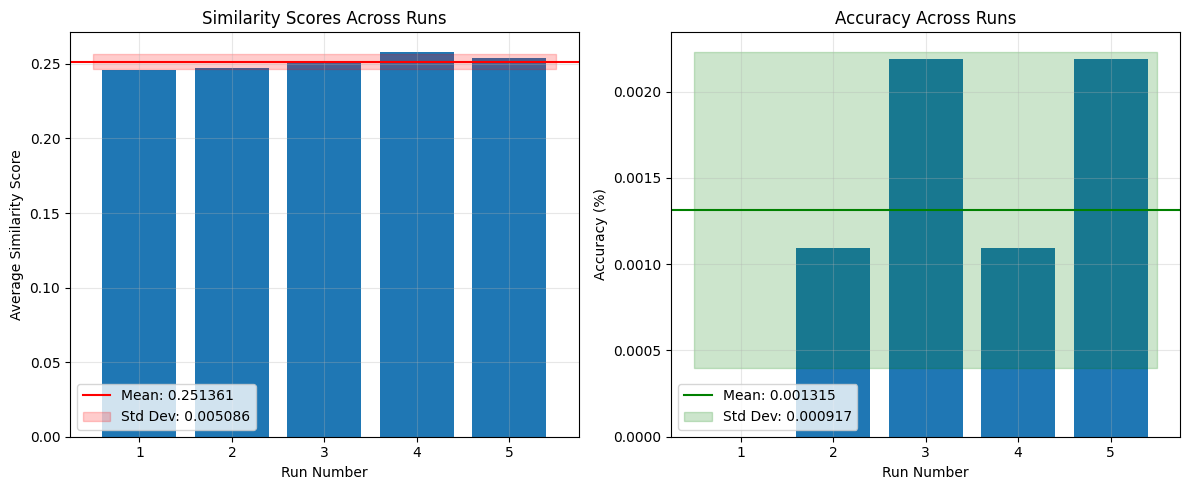

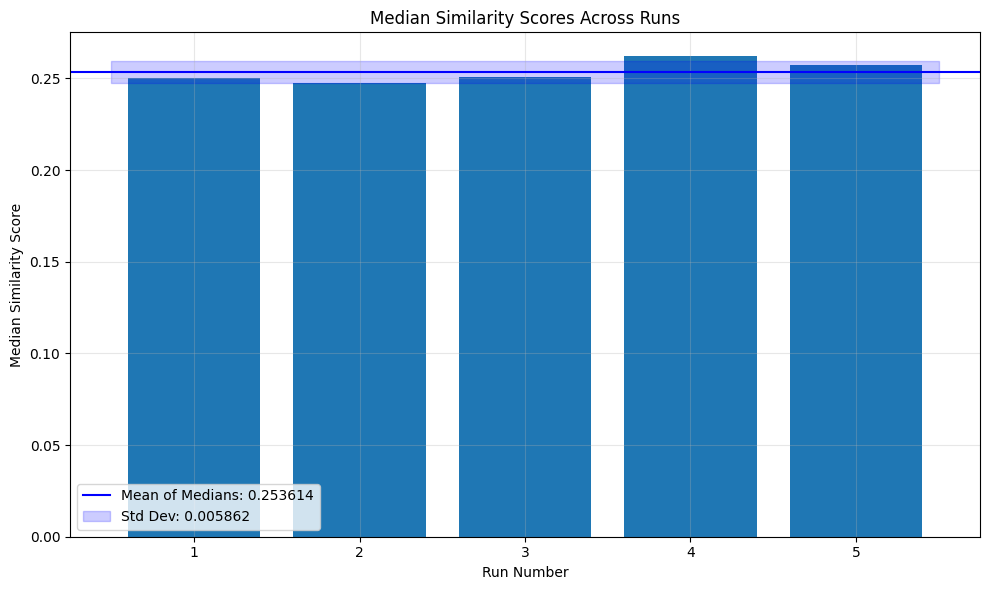

In [28]:
# Plot the similarity results
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.bar(metrics_df['run'], metrics_df['avg_similarity'])
plt.axhline(y=metrics_df['avg_similarity'].mean(), color='r', linestyle='-',
            label=f'Mean: {metrics_df["avg_similarity"].mean():.6f}')
plt.fill_between(
    [0.5, len(metrics_df)+0.5],
    [metrics_df['avg_similarity'].mean() - metrics_df['avg_similarity'].std()]*2,
    [metrics_df['avg_similarity'].mean() + metrics_df['avg_similarity'].std()]*2,
    color='r', alpha=0.2, label=f'Std Dev: {metrics_df["avg_similarity"].std():.6f}'
)
plt.xlabel('Run Number')
plt.ylabel('Average Similarity Score')
plt.title('Similarity Scores Across Runs')
plt.xticks(metrics_df['run'])
plt.legend()
plt.grid(True, alpha=0.3)

# Plot the accuracy results
plt.subplot(1, 2, 2)
plt.bar(metrics_df['run'], metrics_df['pct_correct_matches'])
plt.axhline(y=metrics_df['pct_correct_matches'].mean(), color='g', linestyle='-',
            label=f'Mean: {metrics_df["pct_correct_matches"].mean():.6f}')
plt.fill_between(
    [0.5, len(metrics_df)+0.5],
    [metrics_df['pct_correct_matches'].mean() - metrics_df['pct_correct_matches'].std()]*2,
    [metrics_df['pct_correct_matches'].mean() + metrics_df['pct_correct_matches'].std()]*2,
    color='g', alpha=0.2, label=f'Std Dev: {metrics_df["pct_correct_matches"].std():.6f}'
)
plt.xlabel('Run Number')
plt.ylabel('Accuracy (%)')
plt.title('Accuracy Across Runs')
plt.xticks(metrics_df['run'])
plt.legend()
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Add a new plot for median similarity scores
plt.figure(figsize=(10, 6))
plt.bar(metrics_df['run'], metrics_df['median_similarity'])
plt.axhline(y=metrics_df['median_similarity'].mean(), color='b', linestyle='-',
            label=f'Mean of Medians: {metrics_df["median_similarity"].mean():.6f}')
plt.fill_between(
    [0.5, len(metrics_df)+0.5],
    [metrics_df['median_similarity'].mean() - metrics_df['median_similarity'].std()]*2,
    [metrics_df['median_similarity'].mean() + metrics_df['median_similarity'].std()]*2,
    color='b', alpha=0.2, label=f'Std Dev: {metrics_df["median_similarity"].std():.6f}'
)
plt.xlabel('Run Number')
plt.ylabel('Median Similarity Score')
plt.title('Median Similarity Scores Across Runs')
plt.xticks(metrics_df['run'])
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

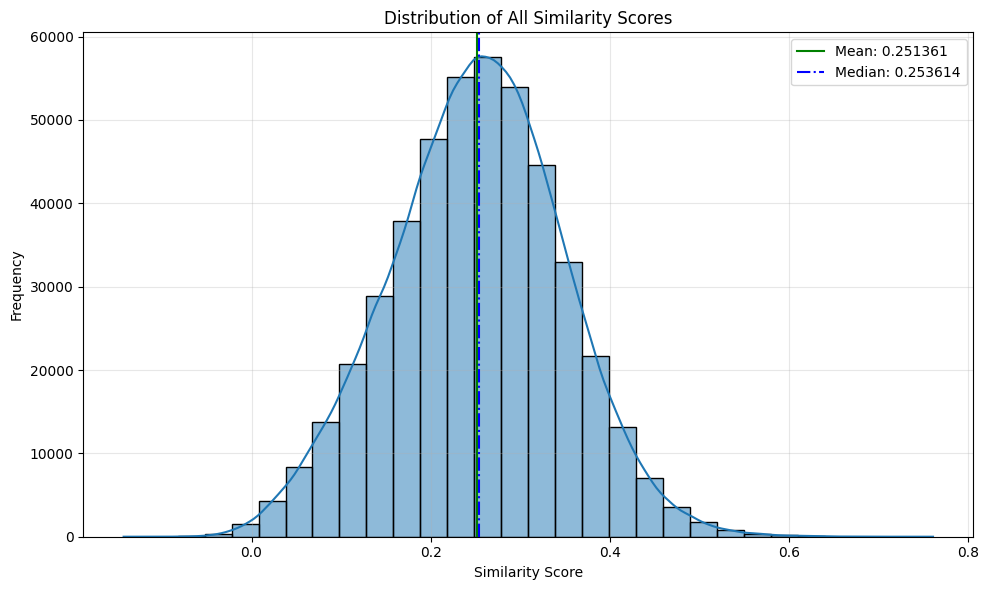

In [29]:
plt.figure(figsize=(10, 6))
sns.histplot(combined_df['similarity_score'], bins=30, kde=True)

# Remove the threshold line
# plt.axvline(x=similarity_threshold, color='r', linestyle='--', label=f'Threshold: {similarity_threshold}')

# Keep mean and median lines
plt.axvline(x=metrics_df['avg_similarity'].mean(), color='g', linestyle='-',
            label=f'Mean: {metrics_df["avg_similarity"].mean():.6f}')
plt.axvline(x=metrics_df['median_similarity'].mean(), color='b', linestyle='-.',
            label=f'Median: {metrics_df["median_similarity"].mean():.6f}')

plt.xlabel('Similarity Score')
plt.ylabel('Frequency')
plt.title('Distribution of All Similarity Scores')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

/tmp/ipython-input-515078.py:4: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(boxplot_data, labels=metrics_df['run'])


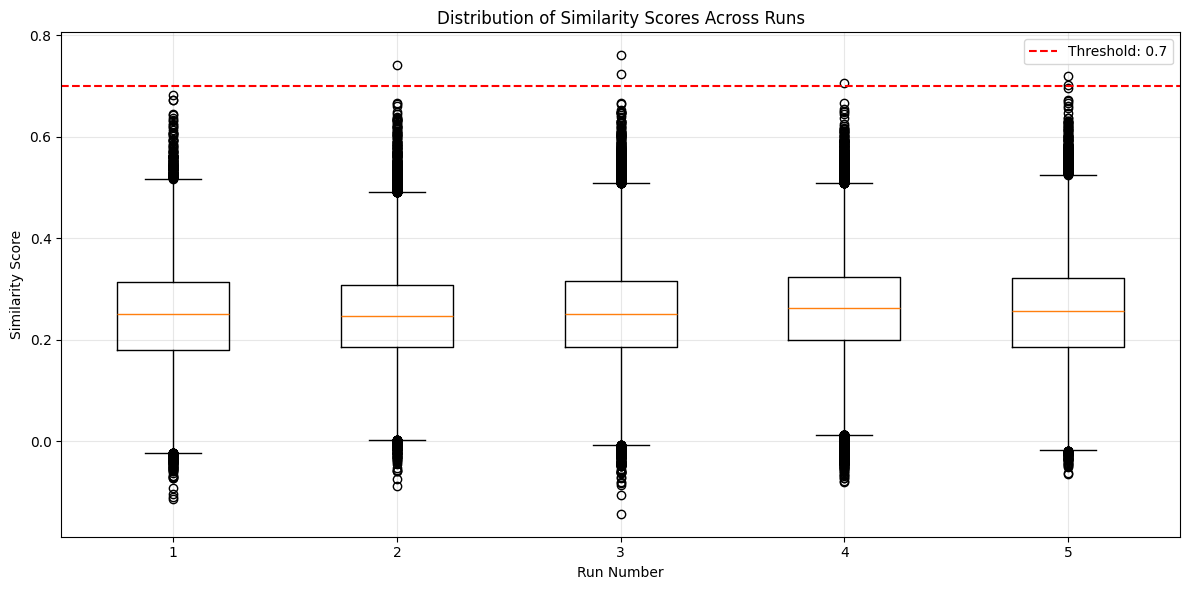

In [30]:
# 3. Box plot of similarity scores across runs
plt.figure(figsize=(12, 6))
boxplot_data = [combined_df[combined_df['run'] == run]['similarity_score'] for run in metrics_df['run']]
plt.boxplot(boxplot_data, labels=metrics_df['run'])
plt.axhline(y=similarity_threshold, color='r', linestyle='--', label=f'Threshold: {similarity_threshold}')
plt.xlabel('Run Number')
plt.ylabel('Similarity Score')
plt.title('Distribution of Similarity Scores Across Runs')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()



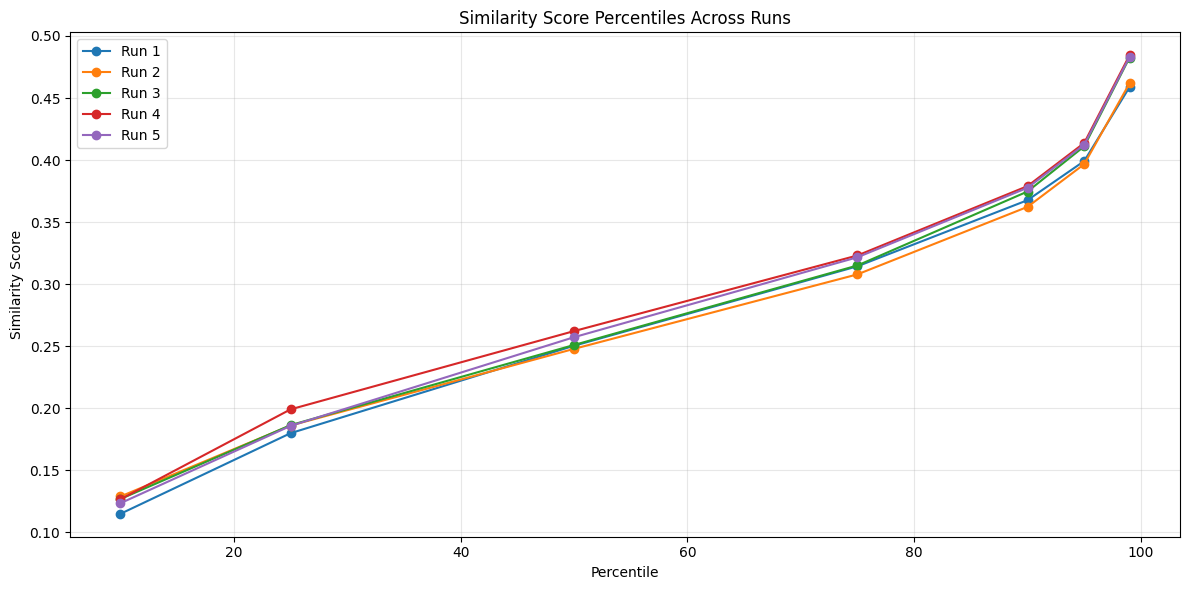

In [31]:
# 4. Percentile analysis
percentiles = [10, 25, 50, 75, 90, 95, 99]
plt.figure(figsize=(12, 6))

for run in metrics_df['run']:
    run_data = combined_df[combined_df['run'] == run]['similarity_score']
    percentile_values = np.percentile(run_data, percentiles)
    plt.plot(percentiles, percentile_values, marker='o', label=f'Run {run}')

plt.xlabel('Percentile')
plt.ylabel('Similarity Score')
plt.title('Similarity Score Percentiles Across Runs')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


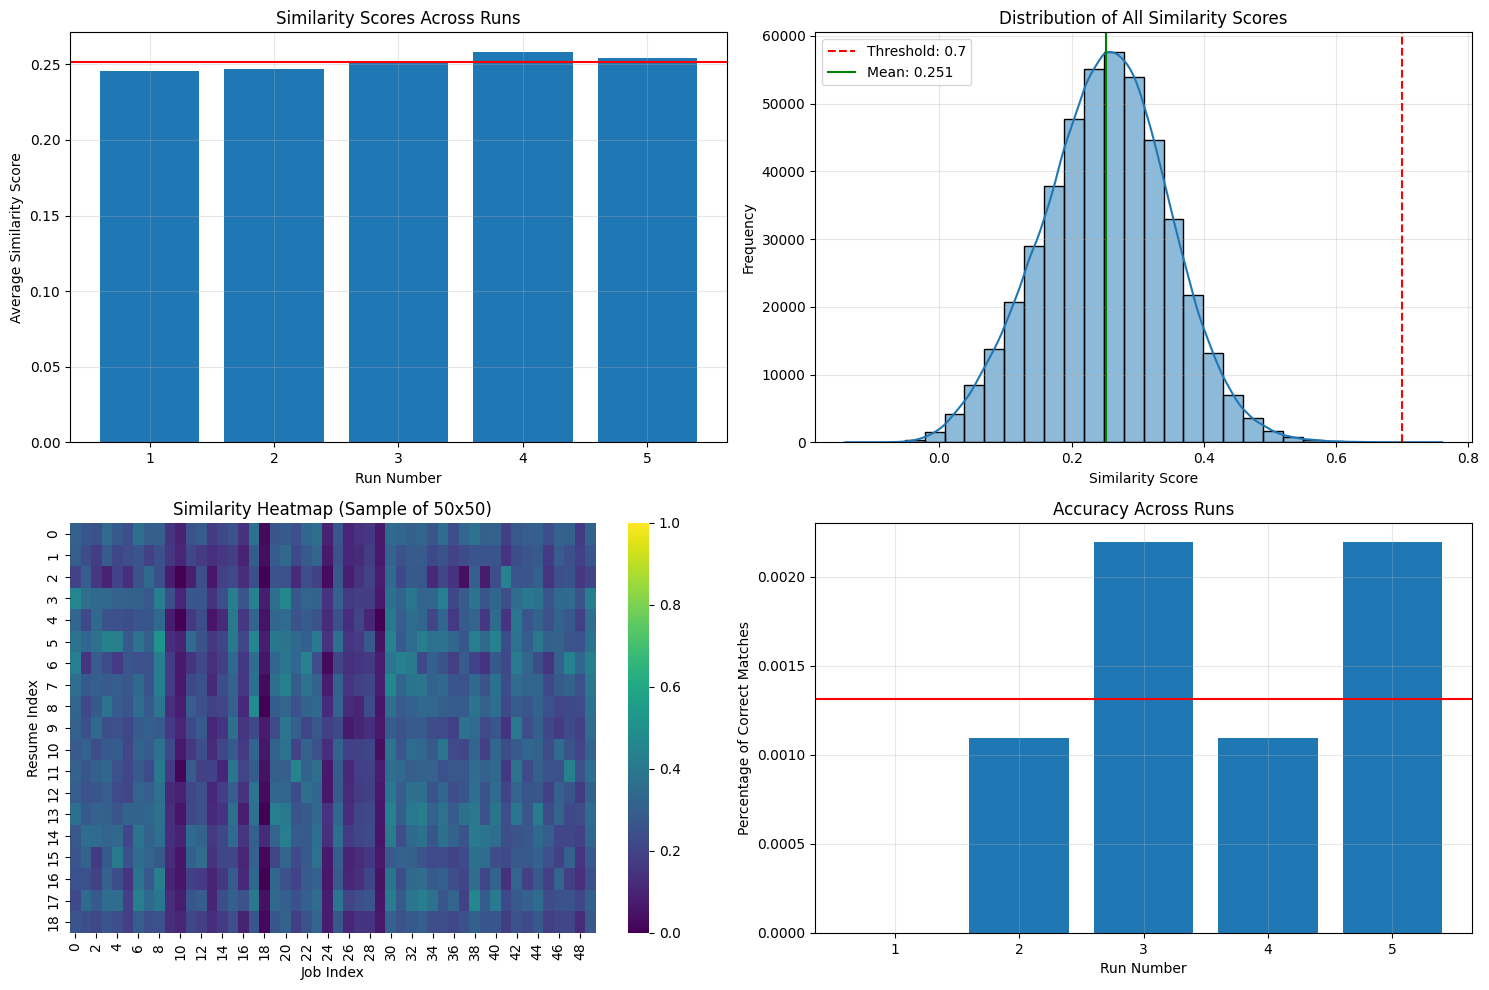


=== EXAMPLES OF HIGH SIMILARITY MATCHES ===

Similarity Score: 0.761
Resume (processed): caring certified compassionate health care assistant several year experience expertise healthcare as...
Resume (before preprocessing): A caring certified and compassionate health care assistant with several years’ experience and expert...
Job (summary): Assistant nurse for the Home Care Service...
--------------------------------------------------

Similarity Score: 0.740
Resume (processed): innovative civil engineer expertise production construction project management strong blueprint inte...
Resume (before preprocessing): I am an innovative Civil Engineer with expertise in production, construction, and project management...
Job (summary): Project Engineer, Construction and Building Technology...
--------------------------------------------------

Similarity Score: 0.723
Resume (processed): compassionate care assistant 4 year experience delivering exceptional care elderly individual specia...
Res

In [32]:
# Create visualizations
plt.figure(figsize=(15, 10))

# Plot 1: Average similarity across runs
plt.subplot(2, 2, 1)
plt.bar(range(1, num_runs + 1), all_similarity_scores)
plt.axhline(y=np.mean(all_similarity_scores), color='r', linestyle='-')
plt.xlabel('Run Number')
plt.ylabel('Average Similarity Score')
plt.title('Similarity Scores Across Runs')
plt.grid(True, alpha=0.3)

# Plot 2: Distribution of similarity scores
plt.subplot(2, 2, 2)
sns.histplot(combined_df['similarity_score'], bins=30, kde=True)
plt.axvline(x=similarity_threshold, color='r', linestyle='--', label=f'Threshold: {similarity_threshold}')
plt.axvline(x=np.mean(all_similarity_scores), color='g', linestyle='-', label=f'Mean: {np.mean(all_similarity_scores):.3f}')
plt.xlabel('Similarity Score')
plt.ylabel('Frequency')
plt.title('Distribution of All Similarity Scores')
plt.legend()
plt.grid(True, alpha=0.3)

# Plot 3: Heatmap of similarity scores (sample)
plt.subplot(2, 2, 3)
sample_size = min(50, len(resume_test))
pivot_df = combined_df[combined_df['run'] == 1].iloc[:sample_size*sample_size]
pivot_matrix = pivot_df.pivot_table(
    index='resume_index',
    columns='job_index',
    values='similarity_score',
    aggfunc='mean'
).iloc[:sample_size, :sample_size]

sns.heatmap(pivot_matrix, cmap='viridis', vmin=0, vmax=1)
plt.title(f'Similarity Heatmap (Sample of {sample_size}x{sample_size})')
plt.xlabel('Job Index')
plt.ylabel('Resume Index')

# Plot 4: Accuracy across runs
plt.subplot(2, 2, 4)
plt.bar(range(1, num_runs + 1), all_accuracy_scores)
plt.axhline(y=np.mean(all_accuracy_scores), color='r', linestyle='-')
plt.xlabel('Run Number')
plt.ylabel('Percentage of Correct Matches')
plt.title('Accuracy Across Runs')
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Show examples of high similarity matches
print("\n=== EXAMPLES OF HIGH SIMILARITY MATCHES ===")
high_sim = combined_df.sort_values('similarity_score', ascending=False).head(3)
for i, row in high_sim.iterrows():
    print(f"\nSimilarity Score: {row['similarity_score']:.3f}")
    print(f"Resume (processed): {row['resume_summary'][:100]}...")
    print(f"Resume (before preprocessing): {row['resume_original'][:100]}...")
    print(f"Job (summary): {row['job_summary'][:100]}...")
    print("-" * 50)

# Show examples of low similarity matches
print("\n=== EXAMPLES OF LOW SIMILARITY MATCHES ===")
low_sim = combined_df.sort_values('similarity_score').head(3)
for i, row in low_sim.iterrows():
    print(f"\nSimilarity Score: {row['similarity_score']:.3f}")
    print(f"Resume (processed): {row['resume_summary'][:100]}...")
    print(f"Resume (before preprocessing): {row['resume_original'][:100]}...")
    print(f"Job (summary): {row['job_summary'][:100]}...")
    print("-" * 50)

# Additional analysis: Distribution of scores by percentile
percentiles = [10, 25, 50, 75, 90, 95, 99]
score_percentiles = np.percentile(combined_df['similarity_score'], percentiles)

print("\n=== SIMILARITY SCORE PERCENTILES ===")
for p, score in zip(percentiles, score_percentiles):
    print(f"{p}th percentile: {score:.3f}")

# Save results to CSV for further analysis
combined_df.to_csv('all_similarity_scores.csv', index=False)
metrics_df.to_csv('evaluation_metrics.csv', index=False)

print("\n=== EVALUATION COMPLETE ===")
print(f"Total matches evaluated: {len(combined_df)}")
print(f"Results saved to CSV files")

In [33]:
# Extract wrong predictions
wrong_preds = combined_df[combined_df['is_correct'] == False]

# Check the distribution of their similarity scores
print("\n=== SIMILARITY SCORES OF WRONG PREDICTIONS ===")
print(wrong_preds['similarity_score'].describe())

# Lowest and highest scores among wrong predictions
print(f"Lowest wrong score: {wrong_preds['similarity_score'].min():.3f}")
print(f"Highest wrong score: {wrong_preds['similarity_score'].max():.3f}")


=== SIMILARITY SCORES OF WRONG PREDICTIONS ===
count    456264.000000
mean          0.251354
std           0.096341
min          -0.142767
25%           0.187235
50%           0.253628
75%           0.316415
max           0.696264
Name: similarity_score, dtype: float64
Lowest wrong score: -0.143
Highest wrong score: 0.696


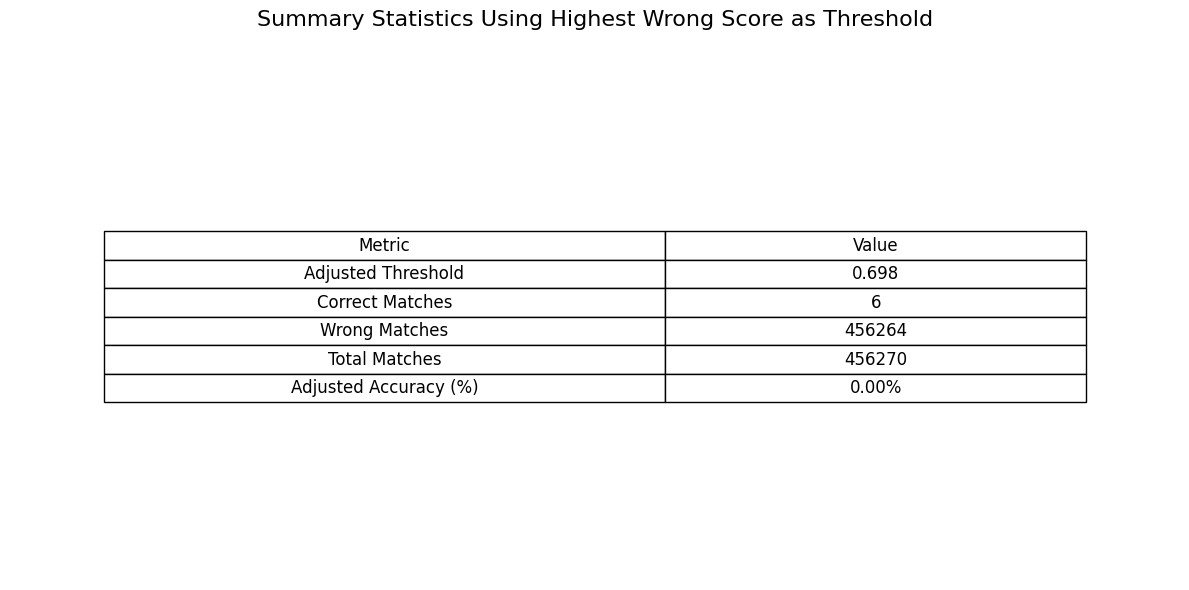

In [35]:
# Set threshold to the highest wrong similarity score
#adjusted_threshold = wrong_preds['similarity_score'].max()
# Set threshold to highest wrong score
adjusted_threshold = 0.698

# Recompute correct/wrong matches based on adjusted threshold
combined_df['is_correct_adjusted'] = combined_df['similarity_score'] >= adjusted_threshold

# Count correct and wrong matches
num_correct = combined_df['is_correct_adjusted'].sum()
num_wrong = len(combined_df) - num_correct
accuracy_adjusted = num_correct / len(combined_df) * 100

# Summary table
plt.figure(figsize=(12, 6))
plt.axis('off')
table_data = [
    ['Metric', 'Value'],
    ['Adjusted Threshold', f"{adjusted_threshold:.3f}"],
    ['Correct Matches', f"{num_correct}"],
    ['Wrong Matches', f"{num_wrong}"],
    ['Total Matches', f"{len(combined_df)}"],
    ['Adjusted Accuracy (%)', f"{accuracy_adjusted:.2f}%"]
]

table = plt.table(cellText=table_data, cellLoc='center', loc='center', colWidths=[0.4, 0.3])
table.auto_set_font_size(False)
table.set_fontsize(12)
table.scale(1.2, 1.5)
plt.title('Summary Statistics Using Highest Wrong Score as Threshold', fontsize=16, pad=20)
plt.tight_layout()
plt.show()